# Chapter 6: Body Composition from CT

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter06_Body_Composition_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is where the course has been going. Everything before it was groundwork:

| From | We take |
|---|---|
| Chapter 1 | Hounsfield units, and slices in the right order and orientation |
| Chapter 2 | Denoise first, restrict to the patient, then threshold |
| Chapter 3 | Pixel counts into cm², and the habit of checking the answer |
| Chapter 4 | Normalizing, so two patients can be compared |

The measurement itself is standardized: on one axial slice at the **third lumbar vertebra (L3)**,
measure the cross-sectional area of skeletal muscle, of the fat under the skin, and of the fat
around the organs. That single slice predicts whole-body composition well enough that it has become
the convention in oncology research.

Three questions have to be answered to get there, and only the third is arithmetic:

1. **Which slice is L3?**
2. **Which pixels are muscle, and which are organ?** Chapter 2 showed a threshold cannot tell.
3. **Which fat is under the skin and which is around the organs?** They have identical HU values.

The answer to 1 and 3 is anatomy, not intensity — which is why this chapter brings in a segmentation
network.

## Setup

This chapter needs **TotalSegmentator**, a pretrained network that labels 117 anatomical structures
in a CT. It brings its own PyTorch and model weights, so the first run downloads a few hundred
megabytes and takes a few minutes. On Colab a GPU runtime makes it much faster.

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import subprocess
import sys

try:
    import totalsegmentator  # noqa: F401
    print("TotalSegmentator already installed")
except ModuleNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "TotalSegmentator", "SimpleITK", "scikit-image"], check=True)
    print("installed")

TotalSegmentator already installed


In [3]:
import os
import pathlib
import shutil

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import SimpleITK as sitk
from skimage.morphology import convex_hull_image

import medimage_data as md

WORK = pathlib.Path("work")
WORK.mkdir(exist_ok=True)


def totalsegmentator_binary():
    """Find the TotalSegmentator executable, wherever it was installed."""
    for candidate in [shutil.which("TotalSegmentator"),
                      ".venv-ts/bin/TotalSegmentator",
                      str(pathlib.Path(sys.executable).parent / "TotalSegmentator")]:
        if candidate and pathlib.Path(candidate).exists():
            return candidate
    raise FileNotFoundError("TotalSegmentator not found")


def run_segmentation(args):
    # Jupyter exports MPLBACKEND=module://matplotlib_inline.backend_inline.
    # TotalSegmentator installed in its own environment rejects that value and
    # dies before it starts, so drop the variable from the child's environment.
    env = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
    subprocess.run(args, check=True, env=env)


# Show the path without the home directory, so the output does not carry
# the username of whoever executed the notebook.
print("using:", str(totalsegmentator_binary()).replace(str(pathlib.Path.home()), "~"))

using: ~/.pyenv/shims/TotalSegmentator


## 1. The scan

TotalSegmentator reads NIfTI rather than a folder of DICOM files, so the series is converted once.
SimpleITK handles both the reading and the geometry, and from here on we work in its array
convention so that the image and the segmentation always share indices — mixing two conventions is
an easy way to measure the wrong slice.

There is one more thing to settle before any of it is drawn. Chapter 1 showed that a DICOM series
does not promise which way its rows run, and this one runs back-to-front: taken as stored, the
patient comes out upside down. `sitk.DICOMOrient` rewrites a volume into a named orientation —
`LPI` here, which turns the rows over and leaves the slice order alone — so every volume below,
the scan and each mask alike, is read through the same helper. Orienting them together is what
keeps their indices aligned; orienting only the image would silently break the correspondence
this section just promised.

In [4]:
ct_dir = md.fetch_pancreas_ct(0)
nifti = WORK / "ct.nii.gz"

if not nifti.exists():
    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(ct_dir)))
    sitk.WriteImage(reader.Execute(), str(nifti))

def read_oriented(path):
    """Read a volume and force it into LPI, so rows run front to back."""
    return sitk.DICOMOrient(sitk.ReadImage(str(path)), "LPI")


image = read_oriented(nifti)
ct = sitk.GetArrayFromImage(image).astype(np.float32)      # (slice, row, column), in HU
sx, sy, sz = image.GetSpacing()

pixel_area_cm2 = sx * sy / 100

print("volume:", ct.shape)
print(f"spacing: {sx:.3f} x {sy:.3f} mm in plane, {sz:.3f} mm between slices")
print(f"HU range: {ct.min():.0f} to {ct.max():.0f}")
print(f"one pixel = {pixel_area_cm2:.5f} cm^2")

PANCREAS_0076: 210 slices in data/pancreas-ct/PANCREAS_0076
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


volume: (210, 512, 512)
spacing: 0.898 x 0.898 mm in plane, 1.000 mm between slices
HU range: -1024 to 1373
one pixel = 0.00807 cm^2


## 2. Finding L3 — and checking the answer

Ask TotalSegmentator for the lumbar vertebrae. Passing `--roi_subset` makes it locate the region
first and then segment it at higher effective resolution, which matters here.

In [5]:
seg_dir = WORK / "vertebrae"

if not (seg_dir / "vertebrae_L3.nii.gz").exists():
    run_segmentation([totalsegmentator_binary(), "-i", str(nifti), "-o", str(seg_dir),
                      "--roi_subset", "vertebrae_L1", "vertebrae_L2", "vertebrae_L3",
                      "vertebrae_L4", "vertebrae_L5"])

def slice_profile(path):
    arr = sitk.GetArrayFromImage(read_oriented(path))
    return arr.reshape(arr.shape[0], -1).sum(axis=1)


print(f"{'vertebra':<14}{'slices':>14}{'extent mm':>11}")
levels = {}
for name in ["vertebrae_L1", "vertebrae_L2", "vertebrae_L3", "vertebrae_L4", "vertebrae_L5"]:
    profile = slice_profile(seg_dir / f"{name}.nii.gz")
    if profile.sum() == 0:
        print(f"{name:<14}{'not in scan':>14}")
        continue
    main = np.where(profile > 0.1 * profile.max())[0]
    levels[name] = main
    print(f"{name:<14}{f'{main.min()}..{main.max()}':>14}{len(main) * sz:>11.0f}")

vertebra              slices  extent mm


vertebrae_L1        100..146         47


vertebrae_L2        135..182         48


vertebrae_L3        173..209         37


vertebrae_L4        204..209          6


vertebrae_L5     not in scan


### Do not trust this yet

A pretrained network returns an answer whether or not the answer is any good, and here the whole
measurement hangs on it. Chapter 3 made the point with Dice; the same discipline applies to a model
you did not train.

Three checks are cheap and catch most failures:

1. **Is each vertebra about the right size?** A lumbar vertebra is roughly 3–4 cm tall.
2. **Are they in order?** Going down the spine must go L1, L2, L3 — never out of sequence.
3. **Is there lung at that level?** There should be none at L3. If there is, the level is wrong.

In [6]:
centers = {name: main.mean() for name, main in levels.items()}
ordered = sorted(centers, key=lambda n: centers[n])

print("order down the scan:", " -> ".join(n.replace("vertebrae_", "") for n in ordered))
print("expected           :", " -> ".join(sorted(n.replace("vertebrae_", "") for n in levels)))
print()

for name, main in levels.items():
    height = len(main) * sz
    verdict = "plausible" if 25 <= height <= 50 else "SUSPICIOUS"
    print(f"  {name:<14} {height:5.0f} mm   {verdict}")

print()
print("A vertebra at the very edge of the scan is cut off and will look too")
print("short - check whether it sits at the first or last slice before worrying.")

order down the scan: L1 -> L2 -> L3 -> L4
expected           : L1 -> L2 -> L3 -> L4

  vertebrae_L1      47 mm   plausible
  vertebrae_L2      48 mm   plausible
  vertebrae_L3      37 mm   plausible
  vertebrae_L4       6 mm   SUSPICIOUS

A vertebra at the very edge of the scan is cut off and will look too
short - check whether it sits at the first or last slice before worrying.


In [7]:
def body_mask(slice_hu, threshold=-500):
    """The patient: largest filled blob above the threshold.

    Taking the largest component is not optional here. Without it the mask also
    swallows the scanner table and the air between it and the patient, which
    makes the air check below read about 17% instead of 2%.
    """
    filled = ndi.binary_fill_holes(slice_hu > threshold)
    labels, n = ndi.label(filled)
    if n == 0:
        return filled
    sizes = ndi.sum_labels(np.ones_like(labels), labels, range(1, n + 1))
    return labels == int(np.argmax(sizes)) + 1


l3 = levels["vertebrae_L3"]
L3_SLICE = int(round(l3.mean()))

body_at_l3 = body_mask(ct[L3_SLICE])
air_inside = np.count_nonzero(body_at_l3 & (ct[L3_SLICE] < -500)) / body_at_l3.sum()

print(f"mid-L3 slice: {L3_SLICE}")
print(f"air inside the body at this level: {air_inside:.1%}")
print("(bowel gas gives a few percent; lung would give tens of percent)")

mid-L3 slice: 191
air inside the body at this level: 1.9%
(bowel gas gives a few percent; lung would give tens of percent)


### A warning worth taking seriously

While preparing this chapter the same scan was segmented three ways, and the answers disagreed:

| How it was run | L3 extent | Verdict |
|---|---|---|
| `--fast` (3 mm model) | 62 mm, two humps | two vertebrae merged into one label |
| full model, all 117 structures | 75 mm, and L4 above L2 | ordering scrambled |
| full model, `--roi_subset` (used here) | 37 mm, L1 → L2 → L3 in order | passes all three checks |

The overlap between the last two was Dice 0.66 — they are materially different answers to the same
question. Had we taken the first result and carried on, every number in this chapter would have come
from the wrong level, and nothing would have looked obviously wrong.

**Run the checks. A confident model is not a correct one.**

## 3. Muscle or organ?

Chapter 2 ended here: liver, spleen and kidney sit in the same HU window as muscle, so no threshold
separates them. Let us see how bad it is.

In [8]:
slice_hu = ct[L3_SLICE]
smooth = ndi.gaussian_filter(slice_hu, 2)

body = body_mask(slice_hu)

naive_muscle = ndi.binary_opening(body & (smooth >= -29) & (smooth < 150), np.ones((3, 3)))

print(f"HU threshold alone: {naive_muscle.sum() * pixel_area_cm2:.1f} cm^2")
print("published range for skeletal muscle at L3: about 90 to 170 cm^2")

HU threshold alone: 314.5 cm^2
published range for skeletal muscle at L3: about 90 to 170 cm^2


Roughly double. The extra area is the abdominal organs.

The fix is anatomy. Segment the organs, then use their outline to define the **abdominal cavity** —
everything the muscular wall encloses. Muscle is what lies outside that boundary; organs and
visceral fat are inside it.

In [9]:
total_seg = WORK / "total.nii"

if not total_seg.exists():
    run_segmentation([totalsegmentator_binary(), "-i", str(nifti),
                      "-o", str(total_seg), "--ml"])

structures = sitk.GetArrayFromImage(read_oriented(total_seg))

# TotalSegmentator label numbers for the abdominal contents.
CAVITY_ORGANS = [1, 2, 3, 5, 6, 7, 18, 20, 52, 53]   # spleen, kidneys, liver, stomach,
                                                      # pancreas, bowel, colon, aorta, IVC

organ_seeds = np.isin(structures[L3_SLICE], CAVITY_ORGANS)
cavity = convex_hull_image(organ_seeds) & body if organ_seeds.any() else np.zeros_like(body)

print(f"organs at this level : {organ_seeds.sum() * pixel_area_cm2:6.1f} cm^2")
print(f"abdominal cavity     : {cavity.sum() * pixel_area_cm2:6.1f} cm^2")

organs at this level :  164.5 cm^2
abdominal cavity     :  293.0 cm^2


The convex hull is a deliberate simplification: it wraps the organs in the smallest convex shape
that contains them, which approximates the inside of the abdominal wall. It is not exact — the real
boundary is a thin sheet of fascia — but it separates the two fat compartments well enough to
measure them, and it needs nothing beyond what TotalSegmentator already gives us.

## 4. The three compartments

Now every piece is in place. Same HU windows as Chapter 2, same cleanup, but each restricted to the
correct anatomical region:

- **Skeletal muscle** — muscle-range HU, inside the body, *outside* the cavity.
- **Subcutaneous fat (SAT)** — fat-range HU, outside the cavity. The fat under the skin.
- **Visceral fat (VAT)** — fat-range HU, *inside* the cavity. The fat packed around the organs.

The split matters clinically. Visceral fat is metabolically active and carries far more
cardiovascular and metabolic risk than the same amount of subcutaneous fat.

In [10]:
def clean(mask):
    mask = ndi.binary_opening(mask, np.ones((3, 3)))
    return ndi.binary_closing(mask, np.ones((3, 3)))


MUSCLE_HU = (-29, 150)
FAT_HU = (-190, -30)

muscle = clean(body & ~cavity & (smooth >= MUSCLE_HU[0]) & (smooth < MUSCLE_HU[1]))
sat = clean(body & ~cavity & (smooth >= FAT_HU[0]) & (smooth < FAT_HU[1]))
vat = clean(body & cavity & (smooth >= FAT_HU[0]) & (smooth < FAT_HU[1]))

muscle_area = muscle.sum() * pixel_area_cm2
sat_area = sat.sum() * pixel_area_cm2
vat_area = vat.sum() * pixel_area_cm2

print(f"skeletal muscle  {muscle_area:7.1f} cm^2   (published range 90-170)")
print(f"subcutaneous fat {sat_area:7.1f} cm^2")
print(f"visceral fat     {vat_area:7.1f} cm^2")
print(f"VAT / SAT ratio  {vat_area / sat_area:7.2f}")
print()
print(f"mean muscle density {slice_hu[muscle].mean():.1f} HU"
      "   (lower means more fat inside the muscle)")

skeletal muscle    161.2 cm^2   (published range 90-170)
subcutaneous fat   193.0 cm^2
visceral fat        83.9 cm^2
VAT / SAT ratio     0.43

mean muscle density 38.6 HU   (lower means more fat inside the muscle)


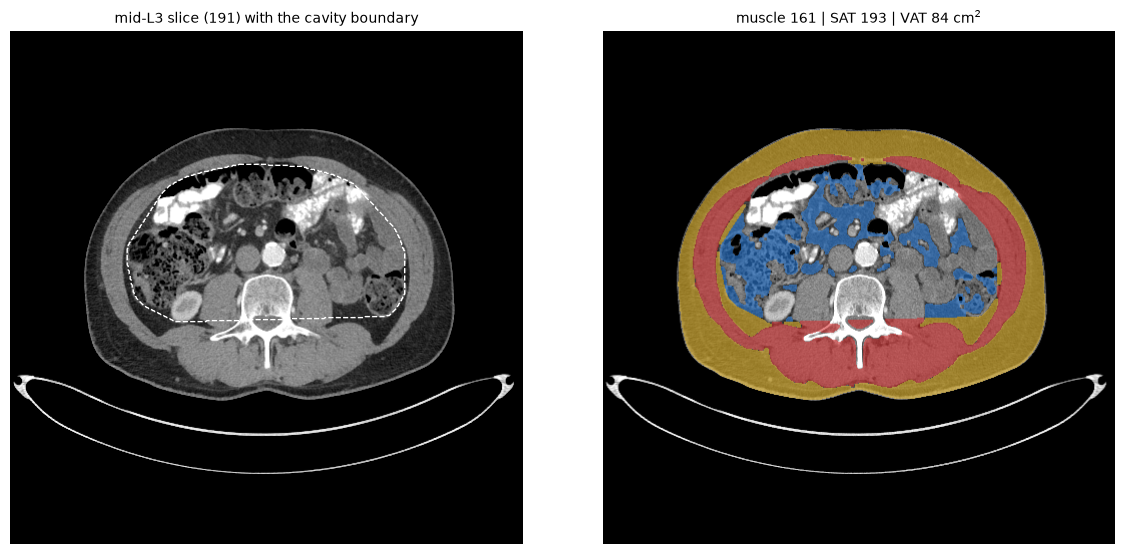

In [11]:
overlay = np.zeros(slice_hu.shape + (3,))
overlay[muscle] = [0.85, 0.15, 0.15]     # red
overlay[sat] = [1.00, 0.80, 0.20]        # yellow
overlay[vat] = [0.20, 0.55, 0.95]        # blue

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
axes[0].imshow(slice_hu, cmap="gray", vmin=-160, vmax=240)
axes[0].contour(cavity, colors="white", linewidths=1.0, linestyles="--")
axes[0].set_title(f"mid-L3 slice ({L3_SLICE}) with the cavity boundary", fontsize=10)
axes[1].imshow(slice_hu, cmap="gray", vmin=-160, vmax=240)
axes[1].imshow(overlay, alpha=np.where(muscle | sat | vat, 0.55, 0.0))
axes[1].set_title(f"muscle {muscle_area:.0f} | SAT {sat_area:.0f} | VAT {vat_area:.0f} cm$^2$",
                  fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Checking against the network's own muscle labels

TotalSegmentator labels two muscle groups directly — the paraspinal muscles (`autochthon`) and the
hip flexors (`iliopsoas`). It does not label the abdominal wall muscles, so its labels are a
*subset* of what we measured. That still makes a useful check: our mask should contain most of
theirs.

In [12]:
ts_muscle = np.isin(structures[L3_SLICE], [86, 87, 88, 89])
captured = np.count_nonzero(muscle & ts_muscle) / ts_muscle.sum()

print(f"TotalSegmentator posterior muscles : {ts_muscle.sum() * pixel_area_cm2:6.1f} cm^2")
print(f"our skeletal muscle measurement    : {muscle_area:6.1f} cm^2")
print(f"share of their muscle inside ours  : {captured:.0%}")
print()
print("Ours is larger because it also includes the abdominal wall, which they do not label.")
print("The shortfall from 100% is where the convex hull clips into the psoas.")

TotalSegmentator posterior muscles :   69.0 cm^2
our skeletal muscle measurement    :  161.2 cm^2
share of their muscle inside ours  : 68%

Ours is larger because it also includes the abdominal wall, which they do not label.
The shortfall from 100% is where the convex hull clips into the psoas.


## 5. Turning areas into an index

Chapter 4's lesson: a raw area partly measures how big the person is. The standard correction is the
**skeletal muscle index**, dividing by height squared:

$$\text{SMI} = \frac{\text{muscle area at L3 (cm}^2)}{\text{height (m)}^2}$$

Widely used cut-offs for low muscle mass are about **41 cm²/m² for women** and **43 cm²/m² for men**.

Height is not recorded in these de-identified scans, so the value below is computed for an assumed
height purely to show the arithmetic. **It is not a measurement of this patient.**

In [13]:
for height_m in [1.60, 1.70, 1.80]:
    smi = muscle_area / height_m ** 2
    flag = "below the cut-off" if smi < 41 else "above the cut-off"
    print(f"if height were {height_m:.2f} m  ->  SMI {smi:5.1f} cm^2/m^2   ({flag})")

print("\nThe muscle area is one number; which side of the cut-off it lands on")
print("depends entirely on a height this dataset does not contain.")

if height were 1.60 m  ->  SMI  63.0 cm^2/m^2   (above the cut-off)
if height were 1.70 m  ->  SMI  55.8 cm^2/m^2   (above the cut-off)
if height were 1.80 m  ->  SMI  49.8 cm^2/m^2   (above the cut-off)

The muscle area is one number; which side of the cut-off it lands on
depends entirely on a height this dataset does not contain.


That is not a footnote — it is the point. The imaging gives you an area. Turning that area into a
clinical statement needs a patient measurement that no scan contains, and getting it wrong moves the
answer across the threshold.

## 6. Limitations

Stated plainly, because every number above has them:

- **The cavity boundary is approximate.** A convex hull is not the abdominal wall. It clips into the
  psoas and cuts corners around the flanks, so the muscle and VAT figures carry a few percent of
  systematic error.
- **The L3 level was verified, not validated.** The three checks catch gross failures; they do not
  prove the level is exactly right, and different run settings gave materially different answers.
- **These are pancreas-protocol scans.** Contrast timing changes organ HU, and published cut-offs
  come from cohorts scanned differently.
- **No height, and no outcomes.** Without them the index cannot be computed and nothing here can be
  checked against what happened to the patient.
- **One slice, one patient.** Chapter 13 shows what it takes to make a claim from a cohort.

None of this makes the method wrong. It makes the numbers *illustrative of the method*, which is
what a teaching notebook can honestly offer.

## Exercises

1. Move `L3_SLICE` up and down by 10 slices and re-measure. How much do muscle and VAT change? What
   does that say about how precisely the level has to be found?
2. Replace the convex hull with `ndi.binary_erosion` of the body mask. Compare all three areas. Which
   compartment is most sensitive to how the boundary is drawn?
3. Run the whole pipeline on `md.fetch_pancreas_ct(1)` and `(2)`. Rank the subjects by muscle area,
   then by VAT/SAT ratio. Do the rankings agree?
4. Compute mean muscle HU for three subjects. Combined with muscle area, which subject would you be
   most concerned about, and what else would you need to know before saying so?

## References

- Mourtzakis M, Prado CM, Lieffers JR, et al. *A practical and precise approach to quantification of
  body composition in cancer patients using computed tomography images acquired during routine care.*
  Appl Physiol Nutr Metab. 2008;33(5):997–1006. — the single-slice L3 method.
- Prado CM, Lieffers JR, McCargar LJ, et al. *Prevalence and clinical implications of sarcopenic
  obesity in patients with solid tumors of the respiratory and gastrointestinal tracts.*
  Lancet Oncology. 2008;9(7):629–635. — the SMI cut-offs.
- Wasserthal J, Breit HC, Meyer MT, et al. *TotalSegmentator: robust segmentation of 104 anatomic
  structures in CT images.* Radiology: Artificial Intelligence. 2023;5(5):e230024.
- Roth H, et al. (2016). *Data From Pancreas-CT.* The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2016.tNB1kqBU](https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU)